# R Programming Assignment 1
Complete solution for Tasks 1–10.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
%load_ext rpy2.ipython

In [7]:
!cp "/content/drive/MyDrive/R_Programming/PRSA_Data_Aotizhongxin_20130301-20170228.csv" "/content/PRSA_Data_Aotizhongxin_20130301-20170228.csv"

## Task 1: Load Data and Initial Exploration

In [14]:
%%R
# Task 1
air_data <- tryCatch({
  read.csv("/content/PRSA_Data_Aotizhongxin_20130301-20170228.csv")
}, error=function(e){cat("Error:",e$message,"\n"); NULL})

if(!is.null(air_data)){
head(air_data); str(air_data); nrow(air_data); ncol(air_data)
any(is.na(air_data)); sum(is.na(air_data))
}

'data.frame':	35064 obs. of  18 variables:
 $ No     : int  1 2 3 4 5 6 7 8 9 10 ...
 $ year   : int  2013 2013 2013 2013 2013 2013 2013 2013 2013 2013 ...
 $ month  : int  3 3 3 3 3 3 3 3 3 3 ...
 $ day    : int  1 1 1 1 1 1 1 1 1 1 ...
 $ hour   : int  0 1 2 3 4 5 6 7 8 9 ...
 $ PM2.5  : num  4 8 7 6 3 5 3 3 3 3 ...
 $ PM10   : num  4 8 7 6 3 5 3 6 6 8 ...
 $ SO2    : num  4 4 5 11 12 18 18 19 16 12 ...
 $ NO2    : num  7 7 10 11 12 18 32 41 43 28 ...
 $ CO     : int  300 300 300 300 300 400 500 500 500 400 ...
 $ O3     : num  77 77 73 72 72 66 50 43 45 59 ...
 $ TEMP   : num  -0.7 -1.1 -1.1 -1.4 -2 -2.2 -2.6 -1.6 0.1 1.2 ...
 $ PRES   : num  1023 1023 1024 1024 1025 ...
 $ DEWP   : num  -18.8 -18.2 -18.2 -19.4 -19.5 -19.6 -19.1 -19.1 -19.2 -19.3 ...
 $ RAIN   : num  0 0 0 0 0 0 0 0 0 0 ...
 $ wd     : chr  "NNW" "N" "NNW" "NW" ...
 $ WSPM   : num  4.4 4.7 5.6 3.1 2 3.7 2.5 3.8 4.1 2.6 ...
 $ station: chr  "Aotizhongxin" "Aotizhongxin" "Aotizhongxin" "Aotizhongxin" ...
[1] 7271


## Task 2: Understanding Missing Values (`NA`, `NULL`, `NaN`)

In [15]:
%%R
# Task 2
temperature<-c(28,30,NA,32)
missing_object<-NULL
undefined_value<-0/0
print(temperature); print(missing_object); print(undefined_value)
print(is.na(temperature)); print(is.null(missing_object)); print(is.nan(undefined_value))

[1] 28 30 NA 32
NULL
[1] NaN
[1] FALSE FALSE  TRUE FALSE
[1] TRUE
[1] TRUE


## Task 3: Summarizing Missing Values

In [16]:
%%R
# Task 3
missing_summary<-function(data){
vars<-c("PM2.5","PM10","SO2","NO2","TEMP","WSPM","wd")
res<-data.frame(Variable=character(),Total_Records=integer(),Missing_Values=integer(),Missing_Percentage=numeric())
for(v in vars){
if(v %in% names(data)){
m<-sum(is.na(data[[v]])); p<-m/nrow(data)*100
res<-rbind(res,data.frame(Variable=v,Total_Records=nrow(data),Missing_Values=m,Missing_Percentage=round(p,2)))
if(p>20) warning(paste(v,"contains >20% missing values"))
}}
res}
missing_summary_table<-missing_summary(air_data); print(missing_summary_table)

  Variable Total_Records Missing_Values Missing_Percentage
1    PM2.5         35064            925               2.64
2     PM10         35064            718               2.05
3      SO2         35064            935               2.67
4      NO2         35064           1023               2.92
5     TEMP         35064             20               0.06
6     WSPM         35064             14               0.04
7       wd         35064             81               0.23


## Task 4: Calculate Pollution Ratio

In [17]:
%%R
# Task 4
air_data$pollution_ratio<-air_data$PM2.5/air_data$PM10
print(sum(is.na(air_data$pollution_ratio)))
print(sum(is.nan(air_data$pollution_ratio)))
print(sum(is.infinite(air_data$pollution_ratio)))
air_data$pollution_ratio[is.nan(air_data$pollution_ratio)|is.infinite(air_data$pollution_ratio)]<-NA

[1] 934
[1] 0
[1] 0


## Task 5: Impute Missing Numeric Values with Median

In [18]:
%%R
# Task 5
numeric_variables<-c("PM2.5","PM10","SO2","NO2","TEMP","WSPM")
for(v in numeric_variables){
if(v %in% names(air_data)){
mb<-sum(is.na(air_data[[v]]))
med<-median(air_data[[v]],na.rm=TRUE)
air_data[[v]][is.na(air_data[[v]])]<-med
ma<-sum(is.na(air_data[[v]]))
cat(v,mb,med,ma,"\n")
}}

PM2.5 925 58 0 
PM10 718 87 0 
SO2 935 9 0 
NO2 1023 53 0 
TEMP 20 14.5 0 
WSPM 14 1.4 0 


## Task 6: Impute Missing Categorical Values with Mode

In [19]:
%%R
# Task 6
calculate_mode<-function(x){x<-x[!is.na(x)]; names(sort(table(x),decreasing=TRUE))[1]}
mb<-sum(is.na(air_data$wd))
mode_wd<-calculate_mode(air_data$wd)
air_data$wd[is.na(air_data$wd)]<-mode_wd
ma<-sum(is.na(air_data$wd))
cat(mode_wd,mb,ma,"\n")

NE 81 0 


## Task 7: Generalized Cleaning Function for Numeric Variables

In [20]:
%%R
# Task 7
clean_variable<-function(data,var){
tryCatch({
if(!(var %in% names(data))) stop("Variable does not exist.")
if(!is.numeric(data[[var]])) stop("Variable is not numerical.")
if(all(is.na(data[[var]]))) stop("Variable contains only missing values.")
med<-median(data[[var]],na.rm=TRUE)
if(is.na(med)) stop("Median cannot be calculated.")
data[[var]][is.na(data[[var]])]<-med
data[[var]]
},error=function(e){cat(e$message,"\n");NULL})
}
for(v in numeric_variables) air_data[[v]]<-clean_variable(air_data,v)

## Task 8: Comparison Table of Missing Values (Before and After Cleaning)

In [21]:
%%R
# Task 8
original_data<-read.csv("/content/PRSA_Data_Aotizhongxin_20130301-20170228.csv")
selected_variables<-c("PM2.5","PM10","SO2","NO2","TEMP","WSPM","wd")
missing_before<-sapply(selected_variables,function(x) sum(is.na(original_data[[x]])))
missing_after<-sapply(selected_variables,function(x) sum(is.na(air_data[[x]])))
comparison_table<-data.frame(Variable=selected_variables,Missing_Before=missing_before,Missing_After=missing_after,Values_Replaced=missing_before-missing_after)
print(comparison_table)

      Variable Missing_Before Missing_After Values_Replaced
PM2.5    PM2.5            925             0             925
PM10      PM10            718             0             718
SO2        SO2            935             0             935
NO2        NO2           1023             0            1023
TEMP      TEMP             20             0              20
WSPM      WSPM             14             0              14
wd          wd             81             0              81


## Task 9: Bar Plot of Missing Values (Before and After Cleaning)

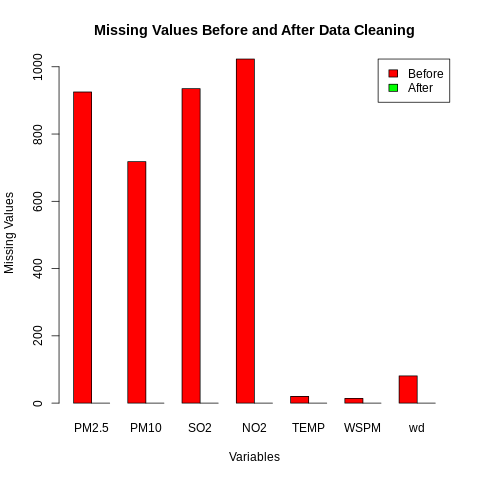

In [22]:
%%R
# Task 9
missing_matrix<-rbind(Missing_Before=missing_before,Missing_After=missing_after)
barplot(missing_matrix,beside=TRUE,col=c("red","green"),names.arg=selected_variables,
main="Missing Values Before and After Data Cleaning",
xlab="Variables",ylab="Missing Values",
legend.text=c("Before","After"),args.legend=list(x="topright"))

## Task 10: Export Cleaned Data

In [23]:
%%R
# Task 10
write.csv(air_data,"cleaned_air_quality_data.csv",row.names=FALSE)

In [10]:
import pandas as pd

cleaned_df = pd.read_csv('/content/cleaned_air_quality_data.csv')
display(cleaned_df.head())

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,pollution_ratio
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,1.0
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,1.0
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,1.0
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin,1.0
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin,1.0


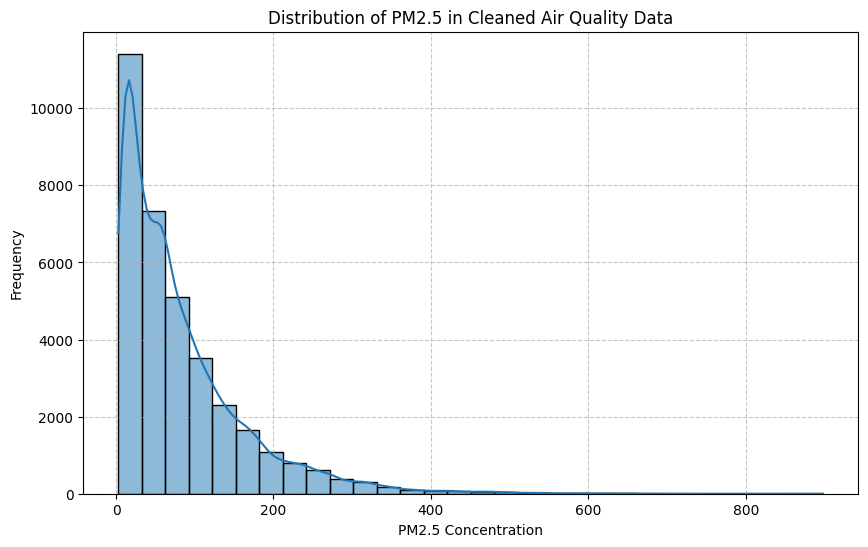

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(cleaned_df['PM2.5'], kde=True, bins=30)
plt.title('Distribution of PM2.5 in Cleaned Air Quality Data')
plt.xlabel('PM2.5 Concentration')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [6]:
!ls /content/drive/MyDrive/R_Programming/

PRSA_Data_Aotizhongxin_20130301-20170228.csv
